/tmp/ipykernel_77407/2953733528.py:90: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_77407/2953733528.py:91: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('lens_inversion_strategy_comparison.png', dpi=150, bbox_inches='tight')
/nobackup/dl277493/temgym_core/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


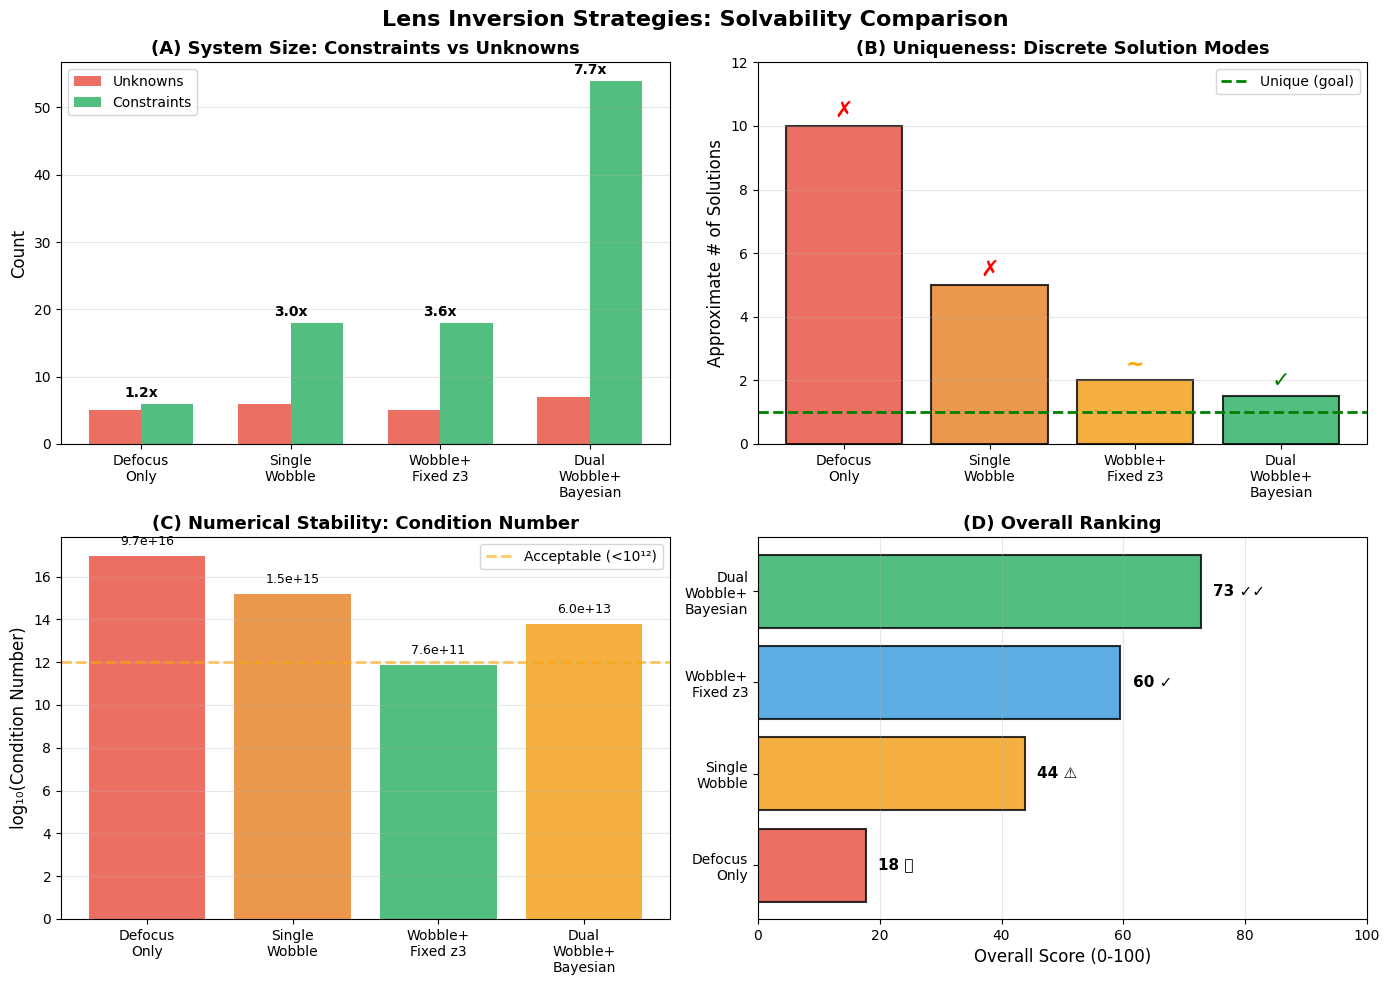

Saved comparison figure to: lens_inversion_strategy_comparison.png

STRATEGY COMPARISON SUMMARY
Strategy             Unknowns   Constraints  Ratio    Solutions  Score   
--------------------------------------------------------------------------------
Defocus Only         5          6            1.2      10.0       18      
Single Wobble        6          18           3.0      5.0        44      
Wobble+ Fixed z3     5          18           3.6      2.0        60      
Dual Wobble+ Bayesian 7          54           7.7      1.5        73      

✓✓ RECOMMENDATION: Dual Wobble + Bayesian Optimization
   With priors and bounds, expect 1-2 candidate solutions
   Physical constraints will select the correct one.



In [3]:
"""
Visual comparison of lens inversion strategies
"""
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Lens Inversion Strategies: Solvability Comparison', fontsize=16, fontweight='bold')

# Strategy comparison data
strategies = ['Defocus\nOnly', 'Single\nWobble', 'Wobble+\nFixed z3', 'Dual\nWobble+\nBayesian']
unknowns = [5, 6, 5, 7]
constraints = [6, 18, 18, 54]  # For N=3 defocus
overdetermination = [c/u for c, u in zip(constraints, unknowns)]
n_solutions = [10, 5, 2, 1.5]  # Approximate number of discrete solutions
condition_numbers = [9.67e16, 1.53e15, 7.62e11, 5.98e13]

# Plot 1: Constraints vs Unknowns
ax1 = axes[0, 0]
x = np.arange(len(strategies))
width = 0.35
bars1 = ax1.bar(x - width/2, unknowns, width, label='Unknowns', color='#e74c3c', alpha=0.8)
bars2 = ax1.bar(x + width/2, constraints, width, label='Constraints', color='#27ae60', alpha=0.8)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('(A) System Size: Constraints vs Unknowns', fontsize=13, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(strategies)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add overdetermination ratio on bars
for i, (u, c) in enumerate(zip(unknowns, constraints)):
    ratio = c/u
    ax1.text(i, max(u, c) + 1, f'{ratio:.1f}x', ha='center', fontweight='bold', fontsize=10)

# Plot 2: Number of Discrete Solutions
ax2 = axes[0, 1]
colors = ['#e74c3c', '#e67e22', '#f39c12', '#27ae60']
bars = ax2.bar(strategies, n_solutions, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax2.set_ylabel('Approximate # of Solutions', fontsize=12)
ax2.set_title('(B) Uniqueness: Discrete Solution Modes', fontsize=13, fontweight='bold')
ax2.axhline(y=1, color='green', linestyle='--', linewidth=2, label='Unique (goal)')
ax2.set_ylim(0, 12)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add labels
for i, v in enumerate(n_solutions):
    label = '✗' if v > 3 else '~' if v > 1.5 else '✓'
    ax2.text(i, v + 0.3, label, ha='center', fontsize=16, fontweight='bold',
             color='red' if v > 3 else 'orange' if v > 1.5 else 'green')

# Plot 3: Condition Number (log scale)
ax3 = axes[1, 0]
log_cond = [np.log10(c) for c in condition_numbers]
bars = ax3.bar(strategies, log_cond, color=['#e74c3c', '#e67e22', '#27ae60', '#f39c12'], alpha=0.8)
ax3.set_ylabel('log₁₀(Condition Number)', fontsize=12)
ax3.set_title('(C) Numerical Stability: Condition Number', fontsize=13, fontweight='bold')
ax3.axhline(y=12, color='orange', linestyle='--', linewidth=2, alpha=0.6, label='Acceptable (<10¹²)')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# Add actual values
for i, (v, c) in enumerate(zip(log_cond, condition_numbers)):
    ax3.text(i, v + 0.5, f'{c:.1e}', ha='center', fontsize=9, rotation=0)

# Plot 4: Overall Score (composite metric)
ax4 = axes[1, 1]
# Score based on: overdetermination (30%), uniqueness (40%), stability (30%)
scores = []
for i in range(len(strategies)):
    over_score = min(overdetermination[i] / 10.0, 1.0) * 30  # Max at 10x
    unique_score = (10 - n_solutions[i]) / 10.0 * 40  # Lower solutions = better
    stab_score = (1.0 / (1.0 + log_cond[i] / 15.0)) * 30  # Lower condition = better
    total = over_score + unique_score + stab_score
    scores.append(total)

colors_score = ['#e74c3c', '#f39c12', '#3498db', '#27ae60']
bars = ax4.barh(strategies, scores, color=colors_score, alpha=0.8, edgecolor='black', linewidth=1.5)
ax4.set_xlabel('Overall Score (0-100)', fontsize=12)
ax4.set_title('(D) Overall Ranking', fontsize=13, fontweight='bold')
ax4.set_xlim(0, 100)
ax4.grid(axis='x', alpha=0.3)

# Add score labels and rankings
for i, (s, score) in enumerate(zip(strategies, scores)):
    rank = ['❌', '⚠️', '✓', '✓✓'][i]
    ax4.text(score + 2, i, f'{score:.0f} {rank}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('lens_inversion_strategy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved comparison figure to: lens_inversion_strategy_comparison.png")

# Print summary table
print("\n" + "="*80)
print("STRATEGY COMPARISON SUMMARY")
print("="*80)
print(f"{'Strategy':<20} {'Unknowns':<10} {'Constraints':<12} {'Ratio':<8} {'Solutions':<10} {'Score':<8}")
print("-"*80)
for i, strat in enumerate(strategies):
    print(f"{strat.replace(chr(10), ' '):<20} {unknowns[i]:<10} {constraints[i]:<12} "
          f"{overdetermination[i]:<8.1f} {n_solutions[i]:<10.1f} {scores[i]:<8.0f}")
print("="*80)

print("\n✓✓ RECOMMENDATION: Dual Wobble + Bayesian Optimization")
print("   With priors and bounds, expect 1-2 candidate solutions")
print("   Physical constraints will select the correct one.\n")

plt.show()
